# SciLM: Scientific Language Model for Electrolyte Formulations

v1 preliminary: any-to-any masked transformer over fixed-length (token_string, scalar) pairs.

Design reference: `SciLM_PLAN.md` in the repo root.

Layout of this notebook:

1. Imports and configuration
2. Load the raw IBM SMI-TED-IC CSVs
3. Build atom-level tokenizer (regex matches SMI-TED's)
4. Assemble the fixed grid: 8 pairs × L = 40 tokens per row
5. Standardization statistics for scalars (%, T, log10 sigma)
6. PyTorch `Dataset` / `DataLoader` with on-the-fly masking + slot permutation
7. SciLM model: token + scalar + slot-position + intra-slot-position embeddings, transformer encoder, two output heads
8. Loss function (CE + lambda * MSE in standardized space)
9. Training loop with running plots of loss curves
10. Sanity-check inference: cross-entropy nearest-SMILES decoding against the 68-molecule inventory

## 1. Imports and configuration

In [12]:
import os
import re
import math
import json
import random
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

DATA_ROOT = Path('data/IBM_SMI_TED_IC/data')
assert DATA_ROOT.exists(), f'data dir not found at {DATA_ROOT.resolve()}'

device: cpu


In [13]:
# =================================================================
#  Run mode: 'sanity' for a quick smoke test, 'full' for real training.
#
#  - 'sanity': tiny model (d_model=64, 2 layers, 2 heads), small batch, 2 epochs.
#    Goal is to confirm the data pipeline, masking, loss, and plotting all work
#    end-to-end and that the train/val losses go down. ~1-3 minutes on CPU.
#
#  - 'full':   the v1 architecture from SciLM_PLAN.md (d_model=256, 6 layers,
#    8 heads), 40 epochs. ~4-12 hours on CPU; ~10-25 minutes on a GPU.
#
#  Flip this string and re-run from this cell down. Nothing else needs to change.
# =================================================================
RUN_MODE = 'full'   # 'sanity' or 'full'

@dataclass
class Config:
    # tokenization / grid
    # L = max atom-token length in the dataset (40) + 1 for <eos_smiles>.
    # The longest SMILES is F[B-](F)(F)OC(C(F)(F)F)(C(F)(F)F)C(F)(F)F.[Li+] at
    # exactly 40 atom tokens, so L must be at least 41 to fit it plus its
    # explicit terminator.
    L: int = 41
    n_pairs: int = 8       # 6 components + temperature + conductivity
    # model
    d_model: int = 256
    n_layers: int = 6
    n_heads: int = 8
    d_ff: int = 1024
    dropout: float = 0.1
    # loss
    lambda_scalar: float = 1.0
    # training
    batch_size: int = 64
    lr: float = 3e-4
    weight_decay: float = 0.01
    n_epochs: int = 40
    warmup_frac: float = 0.05
    # masking
    min_pairs_masked: int = 1
    max_pairs_masked: int = 3
    # slot-permutation augmentation: shuffle slots 1..5 each __getitem__
    permute_solvent_slots: bool = True

if RUN_MODE == 'sanity':
    CFG = Config(
        d_model=64, n_layers=2, n_heads=2, d_ff=128,
        batch_size=32, n_epochs=2, lr=3e-4,
    )
elif RUN_MODE == 'full':
    CFG = Config()
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}; use 'sanity' or 'full'.")

print(f'RUN_MODE={RUN_MODE}')
print(CFG)

RUN_MODE=full
Config(L=41, n_pairs=8, d_model=256, n_layers=6, n_heads=8, d_ff=1024, dropout=0.1, lambda_scalar=1.0, batch_size=64, lr=0.0003, weight_decay=0.01, n_epochs=40, warmup_frac=0.05, min_pairs_masked=1, max_pairs_masked=3, permute_solvent_slots=True)


## 2. Load the raw IBM SMI-TED-IC CSVs

Columns: `smiles` (a `<sep>`-delimited list of six `(SMILES, percentage)` pairs), `temperature` (°C), `ionic` (log10 sigma with sigma in μS/cm).

In [14]:
def parse_row(smiles_field: str) -> List[Tuple[str, float]]:
    """Parse '<sep>'-delimited alternating (smiles, pct, smiles, pct, ...).
    Returns exactly 6 (smi, pct) pairs; unused slots in the source are padded with ('O', 0)."""
    parts = smiles_field.split('<sep>')
    pairs = []
    for i in range(0, len(parts) - 1, 2):
        smi = parts[i].strip()
        pct = parts[i + 1].strip()
        if smi == '':
            continue
        pairs.append((smi, float(pct)))
    assert len(pairs) == 6, f'expected 6 pairs, got {len(pairs)}: {smiles_field[:80]}'
    return pairs

def load_split(name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_ROOT / f'{name}.csv')
    df['pairs'] = df['smiles'].apply(parse_row)
    return df

df_train = load_split('train')
df_valid = load_split('valid')
df_test  = load_split('test')
print('train', len(df_train), 'valid', len(df_valid), 'test', len(df_test))
print('example row:', df_train['pairs'].iloc[0])
print('T:', df_train['temperature'].iloc[0], 'ionic:', df_train['ionic'].iloc[0])

train 8745 valid 2187 test 2734
example row: [('F[P-](F)(F)(F)(F)F.[Li+]', 2.901941), ('CC1COC(=O)O1', 79.84719), ('CCOC(=O)OCC', 17.25087), ('O', 0.0), ('O', 0.0), ('O', 0.0)]
T: -39.4 ionic: 2.770999


## 3. Atom-level tokenizer

Regex identical to SMI-TED's (`data/IBM_SMI_TED_IC/smi_ted_light/load.py`). Vocabulary built from atom tokens present in this dataset, plus our structural specials:

- `<pad>` — fill tokens after `<eos_smiles>` to length L
- `<eos_smiles>` — explicit end-of-SMILES marker
- `<temp>`, `<ionic>` — marker tokens at the start of the temperature and conductivity pairs
- `<mask_tok>` — replaces real tokens at masked positions


In [15]:
SMILES_REGEX = re.compile(
    r"(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
)

def smiles_tokens(smi: str) -> List[str]:
    toks = SMILES_REGEX.findall(smi)
    assert ''.join(toks) == smi, f'tokenizer did not round-trip: {smi!r} -> {toks!r}'
    return toks

# Collect every atom token appearing in the dataset
atom_vocab = set()
unique_smiles = set()
for df in (df_train, df_valid, df_test):
    for pairs in df['pairs']:
        for smi, _ in pairs:
            unique_smiles.add(smi)
            atom_vocab.update(smiles_tokens(smi))
print(f'{len(unique_smiles)} unique SMILES, {len(atom_vocab)} distinct atom tokens')

# Confirm L: each block holds atom tokens + one <eos_smiles> + <pad>s, so L must
# be at least max_atom_len + 1.
max_len = max(len(smiles_tokens(smi)) for smi in unique_smiles)
print(f'observed max SMILES atom-token length = {max_len} | configured L = {CFG.L} (must be >= {max_len + 1})')
assert CFG.L >= max_len + 1, (
    f'CFG.L={CFG.L} too small: need at least {max_len + 1} '
    f'(longest SMILES has {max_len} atom tokens, plus 1 for <eos_smiles>)'
)

SPECIALS = ['<pad>', '<eos_smiles>', '<temp>', '<ionic>', '<mask_tok>']
vocab = SPECIALS + sorted(atom_vocab)
stoi = {t: i for i, t in enumerate(vocab)}
itos = {i: t for t, i in stoi.items()}
PAD_ID  = stoi['<pad>']
EOS_ID  = stoi['<eos_smiles>']
TEMP_ID = stoi['<temp>']
ION_ID  = stoi['<ionic>']
MASK_ID = stoi['<mask_tok>']
V = len(vocab)
print('vocab size', V)

68 unique SMILES, 27 distinct atom tokens
observed max SMILES atom-token length = 40 | configured L = 41 (must be >= 41)
vocab size 32


In [16]:
def encode_smiles_block(smi: str) -> List[int]:
    """Returns L token ids: [atom tokens..., <eos_smiles>, <pad> ...] of length L."""
    toks = smiles_tokens(smi)
    assert len(toks) <= CFG.L - 1, f'SMILES too long ({len(toks)} > {CFG.L - 1}): {smi}'
    ids = [stoi[t] for t in toks]
    ids.append(EOS_ID)
    while len(ids) < CFG.L:
        ids.append(PAD_ID)
    return ids

def encode_marker_block(marker_id: int) -> List[int]:
    """Marker in position 0, pad the rest."""
    return [marker_id] + [PAD_ID] * (CFG.L - 1)

# Pre-encode the fixed 68-molecule inventory; we'll need it at inference.
inventory = sorted(unique_smiles)
inventory_ids = torch.tensor([encode_smiles_block(s) for s in inventory], dtype=torch.long)
print('inventory tensor:', tuple(inventory_ids.shape))

inventory tensor: (68, 41)


## 4. Scalar standardization

Compute mean/std on the train split, freeze, apply everywhere. Three scalar types: percentage (mol %), temperature (°C), conductivity (log10 μS/cm).

In [17]:
all_pcts = np.array([p for pairs in df_train['pairs'] for _, p in pairs], dtype=np.float32)
T_arr = df_train['temperature'].to_numpy(dtype=np.float32)
I_arr = df_train['ionic'].to_numpy(dtype=np.float32)

STATS = {
    'pct':  (float(all_pcts.mean()), float(all_pcts.std())),
    'temp': (float(T_arr.mean()),    float(T_arr.std())),
    'ion':  (float(I_arr.mean()),    float(I_arr.std())),
}
print('standardization stats (mean, std):')
for k, (m, s) in STATS.items():
    print(f'  {k}: mean={m:.4f} std={s:.4f}')

def std_pct(x):  return (x - STATS['pct'][0])  / STATS['pct'][1]
def std_temp(x): return (x - STATS['temp'][0]) / STATS['temp'][1]
def std_ion(x):  return (x - STATS['ion'][0])  / STATS['ion'][1]
def unstd_pct(z):  return z * STATS['pct'][1]  + STATS['pct'][0]
def unstd_temp(z): return z * STATS['temp'][1] + STATS['temp'][0]
def unstd_ion(z):  return z * STATS['ion'][1]  + STATS['ion'][0]

standardization stats (mean, std):
  pct: mean=16.6667 std=25.3602
  temp: mean=11.7288 std=35.6787
  ion: mean=3.3226 std=0.7310


## 5. Dataset: assemble grid, apply masking, permute solvent slots

Each `__getitem__` returns:

- `tokens`: LongTensor of shape (n_pairs, L) with token ids (masked positions → `<mask_tok>`)
- `scalars`: FloatTensor of shape (n_pairs,) — standardized scalar for each pair (value is arbitrary where masked)
- `scalar_mask`: BoolTensor of shape (n_pairs,) — True where the pair's scalar is masked
- `token_mask`: BoolTensor of shape (n_pairs, L) — True where that token position is masked
- `target_tokens`: LongTensor (n_pairs, L) — ground-truth token ids (for computing CE at masked positions)
- `target_scalars`: FloatTensor (n_pairs,) — ground-truth standardized scalars
- `pair_kind`: LongTensor (n_pairs,) — 0=component, 1=temp, 2=ionic (for the scalar MLP / loss bookkeeping)

Pair layout (index 0..7):
- 0: salt (always slot 0 of the source row)
- 1..5: solvents (permuted if `permute_solvent_slots=True`)
- 6: temperature
- 7: conductivity

Masking: sample `k ∈ [min_pairs_masked, max_pairs_masked]` pairs uniformly at random from all 8. For each chosen pair, flip a coin (50/50) between:
- whole-pair mask (a): tokens → `<mask_tok>`, scalar → masked
- scalar-only mask (c): tokens untouched, scalar → masked

In [18]:
PAIR_COMPONENT = 0
PAIR_TEMP = 1
PAIR_ION = 2

class FormulationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config, augment: bool = True, rng_seed: Optional[int] = None):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.augment = augment
        self._rng = random.Random(rng_seed) if rng_seed is not None else random

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        cfg = self.cfg
        row = self.df.iloc[idx]
        pairs = list(row['pairs'])   # list of 6 (smi, pct)
        T = float(row['temperature'])
        I = float(row['ionic'])

        # slot-permutation augmentation on solvents (indices 1..5)
        if self.augment and cfg.permute_solvent_slots:
            solvents = pairs[1:]
            self._rng.shuffle(solvents)
            pairs = [pairs[0]] + solvents

        # build token grid and scalar vector
        tokens = torch.zeros(cfg.n_pairs, cfg.L, dtype=torch.long)
        scalars = torch.zeros(cfg.n_pairs, dtype=torch.float32)
        pair_kind = torch.zeros(cfg.n_pairs, dtype=torch.long)

        for s in range(6):
            smi, pct = pairs[s]
            tokens[s] = torch.tensor(encode_smiles_block(smi), dtype=torch.long)
            scalars[s] = std_pct(pct)
            pair_kind[s] = PAIR_COMPONENT
        tokens[6] = torch.tensor(encode_marker_block(TEMP_ID), dtype=torch.long)
        scalars[6] = std_temp(T); pair_kind[6] = PAIR_TEMP
        tokens[7] = torch.tensor(encode_marker_block(ION_ID),  dtype=torch.long)
        scalars[7] = std_ion(I);  pair_kind[7] = PAIR_ION

        # ground truth copies (before masking)
        target_tokens = tokens.clone()
        target_scalars = scalars.clone()

        # masking: pick k pairs
        k = self._rng.randint(cfg.min_pairs_masked, cfg.max_pairs_masked)
        chosen = self._rng.sample(range(cfg.n_pairs), k)
        token_mask = torch.zeros(cfg.n_pairs, cfg.L, dtype=torch.bool)
        scalar_mask = torch.zeros(cfg.n_pairs, dtype=torch.bool)
        for p in chosen:
            if self._rng.random() < 0.5:
                # (a) whole-pair mask: all tokens + scalar
                tokens[p] = MASK_ID
                token_mask[p] = True
                scalar_mask[p] = True
            else:
                # (c) scalar-only mask
                scalar_mask[p] = True
        return {
            'tokens': tokens,
            'scalars': scalars,
            'scalar_mask': scalar_mask,
            'token_mask': token_mask,
            'target_tokens': target_tokens,
            'target_scalars': target_scalars,
            'pair_kind': pair_kind,
        }

ds_train = FormulationDataset(df_train, CFG, augment=True,  rng_seed=None)
ds_valid = FormulationDataset(df_valid, CFG, augment=False, rng_seed=123)

# quick shape check
b = ds_train[0]
for k, v in b.items():
    print(f'{k:15s} {tuple(v.shape)} {v.dtype}')

tokens          (8, 41) torch.int64
scalars         (8,) torch.float32
scalar_mask     (8,) torch.bool
token_mask      (8, 41) torch.bool
target_tokens   (8, 41) torch.int64
target_scalars  (8,) torch.float32
pair_kind       (8,) torch.int64


## 6. Model: SciLM

Flow per position (i ∈ {0..n_pairs × L − 1}):
```
x_i = E_tok[tok_i]
    + (E_mask_num  if scalar masked else E_num(scalar, pair_kind))
    + E_slot[s_i]
    + E_pos[p_i]
```
Then a stack of transformer encoder layers with batch-first attention.

Two heads:
- `W_tok`: d_model → V, logits per position → CE at masked token positions.
- `W_num`: d_model → 1 at each pair's anchor position (index 0 of the block), regression in standardized space.

In [19]:
class ScalarEncoder(nn.Module):
    """Small MLP embedding a (scalar, pair_kind) pair into a d_model vector.
    Separate MLPs per pair kind (component/temp/ion) so each scalar type can learn
    its own embedding geometry."""
    def __init__(self, d_model: int, n_kinds: int = 3, hidden: int = 64):
        super().__init__()
        self.mlps = nn.ModuleList([
            nn.Sequential(nn.Linear(1, hidden), nn.GELU(), nn.Linear(hidden, d_model))
            for _ in range(n_kinds)
        ])

    def forward(self, x: torch.Tensor, kind: torch.Tensor) -> torch.Tensor:
        # x: (B, n_pairs), kind: (B, n_pairs)
        B, P = x.shape
        D = self.mlps[0][-1].out_features
        out = x.new_zeros(B, P, D)
        x_unsq = x.unsqueeze(-1)  # (B, P, 1)
        for k, mlp in enumerate(self.mlps):
            m = (kind == k)
            if m.any():
                out[m] = mlp(x_unsq[m])
        return out  # (B, P, d_model)

class SciLM(nn.Module):
    def __init__(self, cfg: Config, vocab_size: int):
        super().__init__()
        self.cfg = cfg
        self.V = vocab_size

        self.E_tok  = nn.Embedding(vocab_size, cfg.d_model)
        self.E_slot = nn.Embedding(cfg.n_pairs, cfg.d_model)
        self.E_pos  = nn.Embedding(cfg.L, cfg.d_model)
        # Small-scale init to keep initial logits well-behaved (default nn.Embedding
        # uses N(0, 1), which would make the tied-weight logits explode at step 0).
        nn.init.normal_(self.E_tok.weight,  mean=0.0, std=0.02)
        nn.init.normal_(self.E_slot.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.E_pos.weight,  mean=0.0, std=0.02)
        self.E_mask_num = nn.Parameter(torch.zeros(cfg.d_model))
        nn.init.normal_(self.E_mask_num, std=0.02)
        self.scalar_enc = ScalarEncoder(cfg.d_model, n_kinds=3)

        layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.n_heads,
            dim_feedforward=cfg.d_ff, dropout=cfg.dropout,
            activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=cfg.n_layers)
        self.norm_out = nn.LayerNorm(cfg.d_model)

        # Token head: weight tying with E_tok
        self.W_tok_bias = nn.Parameter(torch.zeros(vocab_size))
        # Scalar head (one per pair kind, applied at that pair's anchor position)
        self.W_num = nn.ModuleList([nn.Linear(cfg.d_model, 1) for _ in range(3)])

        # Precomputed indices
        slot_idx = torch.arange(cfg.n_pairs).unsqueeze(1).expand(cfg.n_pairs, cfg.L)
        pos_idx  = torch.arange(cfg.L).unsqueeze(0).expand(cfg.n_pairs, cfg.L)
        self.register_buffer('slot_idx', slot_idx, persistent=False)
        self.register_buffer('pos_idx',  pos_idx,  persistent=False)

    def forward(self, tokens, scalars, scalar_mask, pair_kind):
        """tokens: (B, P, L)  scalars: (B, P)  scalar_mask: (B, P) bool  pair_kind: (B, P) long"""
        B, P, L = tokens.shape
        D = self.cfg.d_model

        tok_e  = self.E_tok(tokens)                                      # (B, P, L, D)
        slot_e = self.E_slot(self.slot_idx).unsqueeze(0).expand(B, P, L, D)
        pos_e  = self.E_pos(self.pos_idx).unsqueeze(0).expand(B, P, L, D)

        # Scalar contribution: broadcast the pair-level (B, P, D) vector across its L positions
        num_e_pair = self.scalar_enc(scalars, pair_kind)                 # (B, P, D)
        mask_vec = self.E_mask_num.view(1, 1, D).expand(B, P, D)
        num_e_pair = torch.where(scalar_mask.unsqueeze(-1), mask_vec, num_e_pair)
        num_e = num_e_pair.unsqueeze(2).expand(B, P, L, D)

        x = tok_e + slot_e + pos_e + num_e                                # (B, P, L, D)
        x = x.reshape(B, P * L, D)

        # Attention mask: mask out only true <pad> tokens from being attended *to*.
        # Note: we still *predict* at masked positions, but we don't want them attending to pure padding noise.
        key_padding_mask = (tokens.reshape(B, P * L) == PAD_ID)
        h = self.encoder(x, src_key_padding_mask=key_padding_mask)
        h = self.norm_out(h)
        h = h.reshape(B, P, L, D)

        # Token logits via weight tying with E_tok
        tok_logits = torch.einsum('bpld,vd->bplv', h, self.E_tok.weight) + self.W_tok_bias

        # Scalar predictions at each pair's anchor (position 0), per-kind head
        anchor = h[:, :, 0, :]                                             # (B, P, D)
        scalar_pred = torch.zeros(B, P, device=h.device, dtype=h.dtype)
        for k, head in enumerate(self.W_num):
            m = (pair_kind == k)
            if m.any():
                scalar_pred[m] = head(anchor[m]).squeeze(-1)
        return tok_logits, scalar_pred

model = SciLM(CFG, V).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'SciLM params: {n_params/1e6:.2f}M')

SciLM params: 4.81M


/Users/mlawler/.pyenv/versions/3.12.5/envs/ml/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 7. Loss

In [20]:
def scilm_loss(tok_logits, scalar_pred, batch, lam: float):
    """CE on masked token positions + lam * MSE on masked scalar positions (both in standardized space)."""
    B, P, L, V_ = tok_logits.shape
    tok_mask   = batch['token_mask']          # (B, P, L)
    tgt_tok    = batch['target_tokens']       # (B, P, L)
    scal_mask  = batch['scalar_mask']         # (B, P)
    tgt_scal   = batch['target_scalars']      # (B, P)

    if tok_mask.any():
        logits_flat = tok_logits.reshape(-1, V_)
        tgt_flat    = tgt_tok.reshape(-1)
        m           = tok_mask.reshape(-1)
        ce = F.cross_entropy(logits_flat[m], tgt_flat[m])
    else:
        ce = tok_logits.new_zeros(())

    if scal_mask.any():
        m = scal_mask
        mse = F.mse_loss(scalar_pred[m], tgt_scal[m])
    else:
        mse = scalar_pred.new_zeros(())

    return ce + lam * mse, ce.detach(), mse.detach()

## 8. Training loop with live plots

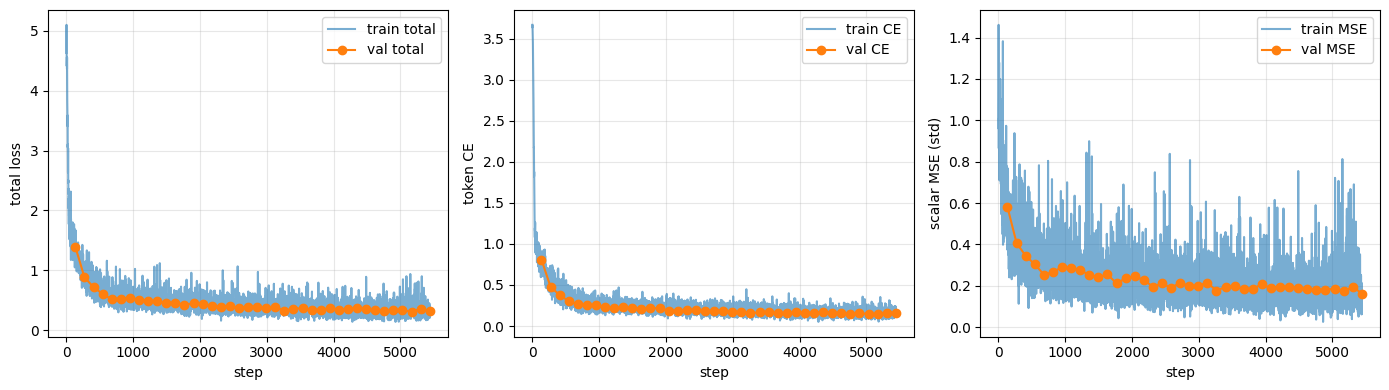

epoch 40/40  train total=0.2739  val total=0.3243  val CE=0.1623  val MSE=0.1620


In [21]:
def collate(batch):
    return {k: torch.stack([b[k] for b in batch], 0) for k in batch[0]}

def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}

dl_train = DataLoader(ds_train, batch_size=CFG.batch_size, shuffle=True,  collate_fn=collate, num_workers=0, drop_last=True)
dl_valid = DataLoader(ds_valid, batch_size=CFG.batch_size, shuffle=False, collate_fn=collate, num_workers=0, drop_last=False)

opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
total_steps = CFG.n_epochs * len(dl_train)
warmup = max(1, int(CFG.warmup_frac * total_steps))
def lr_lambda(step):
    if step < warmup:
        return step / warmup
    prog = (step - warmup) / max(1, total_steps - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * prog))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

history = {'step': [], 'train_total': [], 'train_ce': [], 'train_mse': [],
           'val_epoch': [], 'val_total': [], 'val_ce': [], 'val_mse': []}

def run_val():
    model.eval()
    tot = ce_tot = mse_tot = n = 0
    with torch.no_grad():
        for batch in dl_valid:
            batch = to_device(batch, DEVICE)
            tl, sp = model(batch['tokens'], batch['scalars'], batch['scalar_mask'], batch['pair_kind'])
            loss, ce, mse = scilm_loss(tl, sp, batch, CFG.lambda_scalar)
            bs = batch['tokens'].size(0)
            tot += loss.item() * bs; ce_tot += ce.item() * bs; mse_tot += mse.item() * bs; n += bs
    model.train()
    return tot / n, ce_tot / n, mse_tot / n

def plot_history():
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    steps = history['step']
    axes[0].plot(steps, history['train_total'], label='train total', alpha=0.6)
    if history['val_epoch']:
        axes[0].plot(history['val_epoch'], history['val_total'], 'o-', label='val total')
    axes[0].set_xlabel('step'); axes[0].set_ylabel('total loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(steps, history['train_ce'],  label='train CE',  alpha=0.6)
    if history['val_epoch']:
        axes[1].plot(history['val_epoch'], history['val_ce'],  'o-', label='val CE')
    axes[1].set_xlabel('step'); axes[1].set_ylabel('token CE'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(steps, history['train_mse'], label='train MSE', alpha=0.6)
    if history['val_epoch']:
        axes[2].plot(history['val_epoch'], history['val_mse'], 'o-', label='val MSE')
    axes[2].set_xlabel('step'); axes[2].set_ylabel('scalar MSE (std)'); axes[2].legend(); axes[2].grid(alpha=0.3)
    fig.tight_layout(); plt.show()

model.train()
global_step = 0
for epoch in range(CFG.n_epochs):
    for batch in dl_train:
        batch = to_device(batch, DEVICE)
        tl, sp = model(batch['tokens'], batch['scalars'], batch['scalar_mask'], batch['pair_kind'])
        loss, ce, mse = scilm_loss(tl, sp, batch, CFG.lambda_scalar)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        history['step'].append(global_step)
        history['train_total'].append(loss.item())
        history['train_ce'].append(ce.item())
        history['train_mse'].append(mse.item())
        global_step += 1
    vt, vce, vmse = run_val()
    history['val_epoch'].append(global_step)
    history['val_total'].append(vt); history['val_ce'].append(vce); history['val_mse'].append(vmse)
    plot_history()
    print(f'epoch {epoch+1}/{CFG.n_epochs}  train total={history["train_total"][-1]:.4f}  val total={vt:.4f}  val CE={vce:.4f}  val MSE={vmse:.4f}')

In [26]:
ckpt = {
      'model_state': model.state_dict(),
      'config': vars(CFG),                                                      
      'stats': STATS,
      'vocab': vocab,                                                           
      'history': history,                                                       
}
torch.save(ckpt, 'runs/v1_first_full/checkpoint.pt')                          
import json, pathlib                                                          
pathlib.Path('runs/v1_first_full').mkdir(parents=True, exist_ok=True)         
with open('runs/v1_first_full/history.json', 'w') as f:                       
    json.dump(history, f)                                                     
print('saved')  

saved


## 9. Inference helpers: predict-conductivity and cross-entropy nearest-SMILES

Two primitives:

- `predict_conductivity(pairs, T)` — mask pair 7, return σ prediction in physical units (μS/cm and mS/cm).
- `nearest_smiles_from_logits(logits, block)` — for one masked component pair, pick the inventory SMILES with minimum cross-entropy under `logits`.

In [22]:
@torch.no_grad()
def run_model_single(pairs, T, mask_pairs):
    """pairs: list of 6 (smi, pct); T: float (or None); mask_pairs: set of int indices to mask (0..7)."""
    model.eval()
    tokens = torch.zeros(CFG.n_pairs, CFG.L, dtype=torch.long)
    scalars = torch.zeros(CFG.n_pairs, dtype=torch.float32)
    pair_kind = torch.zeros(CFG.n_pairs, dtype=torch.long)
    for s in range(6):
        smi, pct = pairs[s]
        tokens[s] = torch.tensor(encode_smiles_block(smi), dtype=torch.long)
        scalars[s] = std_pct(pct)
        pair_kind[s] = PAIR_COMPONENT
    tokens[6] = torch.tensor(encode_marker_block(TEMP_ID), dtype=torch.long)
    scalars[6] = std_temp(T if T is not None else 25.0); pair_kind[6] = PAIR_TEMP
    tokens[7] = torch.tensor(encode_marker_block(ION_ID),  dtype=torch.long)
    scalars[7] = 0.0; pair_kind[7] = PAIR_ION

    scalar_mask = torch.zeros(CFG.n_pairs, dtype=torch.bool)
    for p in mask_pairs:
        if p < 6:
            tokens[p] = MASK_ID
        scalar_mask[p] = True

    batch = {k: v.unsqueeze(0).to(DEVICE) for k, v in {
        'tokens': tokens, 'scalars': scalars, 'scalar_mask': scalar_mask, 'pair_kind': pair_kind
    }.items()}
    tok_logits, scalar_pred = model(batch['tokens'], batch['scalars'], batch['scalar_mask'], batch['pair_kind'])
    return tok_logits[0].cpu(), scalar_pred[0].cpu()

def predict_conductivity(pairs, T):
    _, sp = run_model_single(pairs, T, mask_pairs={7})
    z = sp[7].item()
    log10_uS = unstd_ion(z)
    return {
        'log10_sigma_uS_per_cm': log10_uS,
        'sigma_mS_per_cm': 10 ** (log10_uS - 3),
    }

def nearest_smiles_from_logits(logits_block: torch.Tensor) -> Tuple[str, float]:
    """logits_block: (L, V). Returns (best_smiles, best_CE)."""
    logp = F.log_softmax(logits_block, dim=-1)            # (L, V)
    ids = inventory_ids                                    # (N, L)
    N, L = ids.shape
    gathered = logp.gather(-1, ids.T.unsqueeze(-1).reshape(L, N)).squeeze(-1)  # (L, N)
    # average per-position NLL ignoring <pad> positions (after <eos_smiles>)
    nonpad = (ids != PAD_ID).float().T                    # (L, N)
    nll = -(gathered * nonpad).sum(0) / nonpad.sum(0).clamp(min=1)  # (N,)
    best = int(torch.argmin(nll).item())
    return inventory[best], float(nll[best])

# Smoke test: take first test row, ask model for conductivity
row = df_test.iloc[0]
print('truth ionic =', row['ionic'], '  T =', row['temperature'])
print(predict_conductivity(row['pairs'], row['temperature']))

truth ionic = 2.451262   T = -39.4
{'log10_sigma_uS_per_cm': 2.3105511230747737, 'sigma_mS_per_cm': 0.20443305706820025}
